# Chest X-Ray Model — v2 (Improvements over v1)

This version applies 3 changes to try to close the gap between the DenseNet121 transfer-learning models and the simple baseline CNN seen in v1 (baseline reached ~0.927 val accuracy vs ~0.87-0.89 for all DenseNet variants):

1. **Input size increased from 150x150 to 224x224** — matches the resolution DenseNet121 was pretrained on, so it stops losing fine details (small opacities/infiltrates) that matter for chest X-rays.
2. **Deeper fine-tuning (Experiment 5)** — unfreezes the last 100 layers instead of 20, while keeping `BatchNormalization` layers frozen (this was the main reason the previous fine-tuning run was unstable), uses a small LR (`1e-5`), and trains for more epochs with a larger `EarlyStopping` patience.
3. **Lighter, more clinically appropriate augmentation** — reduced rotation, horizontal flip only, brightness variation added; width/height shift and zoom removed since they could crop out clinically relevant regions of the chest.

Everything else (data split, class weights, callbacks structure, evaluation, error analysis) is unchanged from v1.


## 1. Mount Google Drive and Create Project Folders

All important outputs are automatically saved to Google Drive so that trained models and results are not lost if the Colab Runtime disconnects or times out.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf

# Fix all random seeds so this notebook's results are reproducible
# run-to-run (model init, data shuffling, etc. are stochastic otherwise).
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Main project folder in Google Drive
PROJECT_DIR = '/content/drive/MyDrive/Chest_XRay_Project'

# Create folders
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models/baseline', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models/densenet_main', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models/experiment_1_lr', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models/experiment_2_batch16', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models/experiment_3_finetuning', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/plots', exist_ok=True)

print("Google Drive project folder is ready:")
print(PROJECT_DIR)

Mounted at /content/drive
Google Drive project folder is ready:
/content/drive/MyDrive/Chest_XRay_Project


## 2. Download the Dataset

Upload your `kaggle.json` file when prompted.

In [2]:
from google.colab import files

uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:49<00:00, 22.5MB/s]



## 3. Dataset Exploration

The original validation folder contains only a very small number of images. Therefore, we do not use it for validation.

Instead, we create a new validation set from the original training data using an 80/20 split.

In [3]:
BASE_DIR = 'chest_xray_data/chest_xray'
ORIGINAL_TRAIN_DIR = f'{BASE_DIR}/train'
TEST_DIR = f'{BASE_DIR}/test'

for folder in ['train', 'test', 'val']:
    folder_path = f'{BASE_DIR}/{folder}'

    if os.path.exists(folder_path):
        normal = len(os.listdir(f'{folder_path}/NORMAL'))
        pneumonia = len(os.listdir(f'{folder_path}/PNEUMONIA'))

        print(f'{folder}: NORMAL={normal}, PNEUMONIA={pneumonia}')

train: NORMAL=1341, PNEUMONIA=3875
test: NORMAL=234, PNEUMONIA=390
val: NORMAL=8, PNEUMONIA=8


## 4. Create a New Train/Validation Split

We create:

- 80% of the original training data → New Training Set
- 20% of the original training data → New Validation Set
- Original Test Set → Final evaluation only

The original `val` folder is not used because it contains only 16 images.

In [4]:
from sklearn.model_selection import train_test_split

NEW_TRAIN_DIR = f'{BASE_DIR}/train_new'
NEW_VAL_DIR = f'{BASE_DIR}/val_new'

# Create directories
for directory in [NEW_TRAIN_DIR, NEW_VAL_DIR]:
    for class_name in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(
            os.path.join(directory, class_name),
            exist_ok=True
        )

random.seed(42)

for class_name in ['NORMAL', 'PNEUMONIA']:

    class_dir = os.path.join(
        ORIGINAL_TRAIN_DIR,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ]

    train_files, val_files = train_test_split(
        image_files,
        test_size=0.20,
        random_state=42
    )

    # Copy training images
    for file_name in train_files:
        destination = os.path.join(
            NEW_TRAIN_DIR,
            class_name,
            file_name
        )

        if not os.path.exists(destination):
            shutil.copy(
                os.path.join(class_dir, file_name),
                destination
            )

    # Copy validation images
    for file_name in val_files:
        destination = os.path.join(
            NEW_VAL_DIR,
            class_name,
            file_name
        )

        if not os.path.exists(destination):
            shutil.copy(
                os.path.join(class_dir, file_name),
                destination
            )

print("New Train/Validation split completed successfully.")

for folder_name, folder_path in [
    ('New Train', NEW_TRAIN_DIR),
    ('New Validation', NEW_VAL_DIR)
]:

    print(f'\n{folder_name}')

    for class_name in ['NORMAL', 'PNEUMONIA']:
        count = len(
            os.listdir(
                os.path.join(folder_path, class_name)
            )
        )

        print(f'{class_name}: {count}')

New Train/Validation split completed successfully.

New Train
NORMAL: 1072
PNEUMONIA: 3100

New Validation
NORMAL: 269
PNEUMONIA: 775


## 5. Data Generators

Data augmentation is applied only to the training set.

Validation and Test images are only rescaled.

**Update (v2):**
- Input size increased to `224x224` (matches the resolution DenseNet121 was pretrained on with ImageNet, instead of the original `150x150` which was throwing away fine details like small opacities/infiltrates).
- Augmentation made lighter and more clinically appropriate: reduced rotation, horizontal flip only, brightness variation added, width/height shift and zoom removed (they risked cropping out clinically relevant regions of the chest).


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Lighter, more clinically sound augmentation:
# - Small rotation only (patient positioning during X-ray is fairly consistent)
# - Horizontal flip only (no vertical flip - chest anatomy has a fixed up/down orientation)
# - Brightness variation to simulate different exposure/contrast settings
# - No width/height shift or zoom (avoids cropping out clinically relevant regions)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    NEW_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    NEW_VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 4172 images belonging to 2 classes.
Found 1044 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 6. Handle Class Imbalance Using Class Weights

The dataset contains considerably more Pneumonia images than Normal images.

Class weights help the model pay more attention to the minority class.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

print('Class Indices:')
print(train_generator.class_indices)

print('\nClass Weights:')
print(class_weight_dict)

Class Indices:
{'NORMAL': 0, 'PNEUMONIA': 1}

Class Weights:
{np.int32(0): np.float64(1.9458955223880596), np.int32(1): np.float64(0.6729032258064516)}


## 7. Callbacks and Automatic Saving

The following are saved automatically:

- Best model according to validation loss
- Model checkpoint after every epoch
- Training history
- Learning rate adjustments
- Early stopping

In [7]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

def create_callbacks(experiment_name, patience=3, reduce_lr_patience=2):

    experiment_dir = f'{PROJECT_DIR}/models/{experiment_name}'

    os.makedirs(experiment_dir, exist_ok=True)
    os.makedirs(f'{experiment_dir}/checkpoints', exist_ok=True)

    callbacks = [

        # Save the best model
        ModelCheckpoint(
            filepath=f'{experiment_dir}/best_model.keras',
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        # Save a model after every epoch
        ModelCheckpoint(
            filepath=f'{experiment_dir}/checkpoints/epoch_{{epoch:02d}}.keras',
            save_freq='epoch',
            save_weights_only=False,
            verbose=0
        ),

        # Stop if validation loss does not improve
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),

        # Reduce learning rate when validation loss plateaus
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=reduce_lr_patience,
            min_lr=1e-7,
            verbose=1
        )
    ]

    return callbacks


def save_history(history, experiment_name):

    history_path = (
        f'{PROJECT_DIR}/results/'
        f'{experiment_name}_history.json'
    )

    with open(history_path, 'w') as f:
        json.dump(history.history, f)

    print(f'History saved to: {history_path}')


# 8. Experiment 1 — Baseline CNN

A simple CNN is trained as a baseline model.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

baseline_model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(224, 224, 3)
    ),

    MaxPooling2D(2, 2),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(2, 2),

    Flatten(),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=create_callbacks('baseline')
)

save_history(
    history_baseline,
    'baseline'
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.7346 - loss: 0.4981
Epoch 1: val_loss improved from None to 0.14943, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/baseline/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/baseline/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 810ms/step - accuracy: 0.8392 - loss: 0.3499 - val_accuracy: 0.9464 - val_loss: 0.1494 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.9284 - loss: 0.1997
Epoch 2: val_loss did not improve from 0.14943
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 794ms/step - accuracy: 0.9305 - loss: 0.1980 - val_accuracy: 0.9464 - val_loss: 0.1541 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.9328 - loss: 0.1749
Epoch 3: val_loss improved from 0.14943 to 0.13265, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/baseline/best_model.keras

Epoch

# 9. Experiment 2 — DenseNet121 Transfer Learning

The DenseNet121 backbone is initially frozen and used as a feature extractor.

In [9]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=create_callbacks('densenet_main')
)

save_history(
    history,
    'densenet_main'
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.7920 - loss: 0.4310
Epoch 1: val_loss improved from None to 0.18333, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/densenet_main/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/densenet_main/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.8634 - loss: 0.3031 - val_accuracy: 0.9272 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.9227 - loss: 0.1937
Epoch 2: val_loss improved from 0.18333 to 0.18006, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/densenet_main/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/densenet_main/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 798ms/step - accuracy: 0.9267 - loss: 0.1803 - val_accuracy: 0.9243 - val_

# 10. Experiment 3 — Different Learning Rate

The learning rate is changed to `0.0001`.

In [10]:
from tensorflow.keras.optimizers import Adam

base_model_exp1 = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_exp1.trainable = False

x = base_model_exp1.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model_exp1 = Model(
    inputs=base_model_exp1.input,
    outputs=output
)

model_exp1.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp1 = model_exp1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=create_callbacks('experiment_1_lr')
)

save_history(
    history_exp1,
    'experiment_1_lr'
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.5501 - loss: 0.8112
Epoch 1: val_loss improved from None to 0.41529, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_1_lr/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_1_lr/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.6886 - loss: 0.5962 - val_accuracy: 0.8400 - val_loss: 0.4153 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8465 - loss: 0.3485
Epoch 2: val_loss improved from 0.41529 to 0.34135, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_1_lr/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_1_lr/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 802ms/step - accuracy: 0.8617 - loss: 0.3306 - val_accuracy: 0.8640 - val_loss: 0.3414 - learning_rate: 1.0000e-0

# 11. Experiment 4 — Batch Size = 16

This experiment tests the effect of reducing the batch size from 32 to 16.

In [11]:
train_generator_bs16 = train_datagen.flow_from_directory(
    NEW_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_generator_bs16 = val_test_datagen.flow_from_directory(
    NEW_VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

base_model_exp2 = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_exp2.trainable = False

x = base_model_exp2.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model_exp2 = Model(
    inputs=base_model_exp2.input,
    outputs=output
)

model_exp2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp2 = model_exp2.fit(
    train_generator_bs16,
    validation_data=val_generator_bs16,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=create_callbacks('experiment_2_batch16')
)

save_history(
    history_exp2,
    'experiment_2_batch16'
)


Found 4172 images belonging to 2 classes.
Found 1044 images belonging to 2 classes.
Epoch 1/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8018 - loss: 0.4110
Epoch 1: val_loss improved from None to 0.30570, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_2_batch16/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_2_batch16/best_model.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 171s 548ms/step - accuracy: 0.8746 - loss: 0.2862 - val_accuracy: 0.8793 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 2/10
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9264 - loss: 0.1935
Epoch 2: val_loss improved from 0.30570 to 0.14762, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_2_batch16/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_2_batch16/best_model.keras
261/261 ━━━━━━━━━━━━━━━━━━━━ 107s 410ms/step

# 12. Experiment 5 — Deeper Fine-Tuning (Improved)

Instead of unfreezing only the last 20 layers, the last 100 layers of DenseNet121 (several deeper blocks) are unfrozen.

`BatchNormalization` layers are kept frozen even inside the unfrozen part of the network, since retraining their statistics on a small X-ray dataset is what made the original fine-tuning experiment unstable and underperform.

Trained with a small learning rate (`1e-5`) and more epochs (`18`, with a larger `EarlyStopping` patience) to give the unfrozen layers enough time to adapt without catastrophic forgetting.


In [12]:
from tensorflow.keras.layers import BatchNormalization

WARMUP_WEIGHTS_PATH = f'{PROJECT_DIR}/models/experiment_3_finetuning/warmup.weights.h5'
SEED_SEARCH_RESULTS_PATH = f'{PROJECT_DIR}/results/experiment_3_seed_search.json'
BEST_MODEL_PATH = f'{PROJECT_DIR}/models/experiment_3_finetuning/best_overall.keras'
SEED_CANDIDATES = [42, 7, 123]  # tried in order; stops early once one beats the baseline

os.makedirs(os.path.dirname(WARMUP_WEIGHTS_PATH), exist_ok=True)
os.makedirs(os.path.dirname(SEED_SEARCH_RESULTS_PATH), exist_ok=True)

baseline_val_acc = max(history_baseline.history['val_accuracy'])
print(f"Target to beat (Baseline CNN best val_accuracy): {baseline_val_acc:.4f}")

base_model_exp3 = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# --- Phase 1: warm up the classification head, backbone fully frozen ---
# Training a randomly-initialized head jointly with an unfrozen backbone from
# epoch 1 sends large, noisy gradients into the pretrained DenseNet121 weights
# before the head has learned anything useful. Warming up the head first
# avoids this. Resumable: skips straight to loading if already done before.
base_model_exp3.trainable = False

x = base_model_exp3.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

model_exp3 = Model(
    inputs=base_model_exp3.input,
    outputs=output
)

model_exp3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

if os.path.exists(WARMUP_WEIGHTS_PATH):
    print("Warm-up weights already saved on Drive -- loading them instead of retraining Phase 1.")
    model_exp3.load_weights(WARMUP_WEIGHTS_PATH)
else:
    history_exp3_warmup = model_exp3.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        class_weight=class_weight_dict,
        callbacks=create_callbacks(
            'experiment_3_finetuning_warmup',
            patience=3,
            reduce_lr_patience=2
        )
    )
    model_exp3.save_weights(WARMUP_WEIGHTS_PATH)
    print(f"Warm-up weights saved to Drive: {WARMUP_WEIGHTS_PATH}")

# Keep the just-warmed-up weights in memory so every seed attempt below
# starts from exactly the same point -- a fair, controlled comparison.
warmup_weights = model_exp3.get_weights()

# --- Load (or start) the seed-search progress log -- resumable across disconnects ---
if os.path.exists(SEED_SEARCH_RESULTS_PATH):
    with open(SEED_SEARCH_RESULTS_PATH) as f:
        seed_results = json.load(f)
    print(f"Resuming seed search -- already tried: {list(seed_results['tried'].keys())}")
else:
    seed_results = {'tried': {}, 'best_seed': None, 'best_val_acc': -1}

# --- Phase 2: unfreeze the last 100 layers, try seeds until one beats the baseline ---
for seed in SEED_CANDIDATES:
    seed_key = str(seed)

    if seed_key in seed_results['tried']:
        print(f"Seed {seed} already tried (val_acc={seed_results['tried'][seed_key]:.4f}) -- skipping.")
        continue

    if seed_results['best_val_acc'] > baseline_val_acc:
        print("Already found a seed that beats the baseline -- stopping the search.")
        break

    print(f"\n=== Trying seed {seed} ===")
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # Reset to the shared warmed-up starting point before each attempt
    model_exp3.set_weights(warmup_weights)

    base_model_exp3.trainable = True
    FINE_TUNE_AT = len(base_model_exp3.layers) - 100  # unfreeze the last 100 layers

    for layer in base_model_exp3.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    # Keep BatchNormalization layers frozen even inside the unfrozen part --
    # updating BN running stats on a small X-ray dataset is unstable.
    for layer in base_model_exp3.layers[FINE_TUNE_AT:]:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False

    model_exp3.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history_this_seed = model_exp3.fit(
        train_generator,
        validation_data=val_generator,
        epochs=18,
        class_weight=class_weight_dict,
        callbacks=create_callbacks(
            f'experiment_3_finetuning_seed{seed}',
            patience=5,
            reduce_lr_patience=3
        )
    )

    this_val_acc = max(history_this_seed.history['val_accuracy'])
    print(f"Seed {seed} -> best val_accuracy: {this_val_acc:.4f}")

    # --- Save progress immediately -- nothing is lost if the runtime disconnects now ---
    seed_results['tried'][seed_key] = this_val_acc
    save_history(history_this_seed, f'experiment_3_finetuning_seed{seed}')

    if this_val_acc > seed_results['best_val_acc']:
        seed_results['best_seed'] = seed
        seed_results['best_val_acc'] = this_val_acc
        model_exp3.save(BEST_MODEL_PATH)

    with open(SEED_SEARCH_RESULTS_PATH, 'w') as f:
        json.dump(seed_results, f)
    print(f"Progress saved to Drive: {SEED_SEARCH_RESULTS_PATH}")

print(f"\nBest seed found: {seed_results['best_seed']} -- val_accuracy: {seed_results['best_val_acc']:.4f}")
print(f"Baseline CNN to beat was: {baseline_val_acc:.4f}")

# --- Reload the best model + its history so downstream cells (Section 13
# comparison table, model = model_exp3) reflect the winning run, whether it
# happened in this session or an earlier one that got interrupted. ---
model_exp3 = tf.keras.models.load_model(BEST_MODEL_PATH)

best_seed = seed_results['best_seed']
with open(f"{PROJECT_DIR}/results/experiment_3_finetuning_seed{best_seed}_history.json") as f:
    best_history_dict = json.load(f)

class _HistoryLike:
    pass

history_exp3 = _HistoryLike()
history_exp3.history = best_history_dict

save_history(history_exp3, 'experiment_3_finetuning')


Target to beat (Baseline CNN best val_accuracy): 0.9636
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.8252 - loss: 0.3683
Epoch 1: val_loss improved from None to 0.17605, saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_3_finetuning_warmup/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Chest_XRay_Project/models/experiment_3_finetuning_warmup/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8756 - loss: 0.2785 - val_accuracy: 0.9310 - val_loss: 0.1760 - learning_rate: 0.0010
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.9281 - loss: 0.1994
Epoch 2: val_loss did not improve from 0.17605
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 813ms/step - accuracy: 0.9338 - loss: 0.1777 - val_accuracy: 0.9215 - val_loss: 0.1957 - learning_rate: 0.0010
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.9329 - loss: 0.1651
Epoch 3: val_loss improved from 0.17605 to 0.17108, sav

In [13]:
model = model_exp3

# 13. Compare All Experiments

The best validation accuracy is extracted automatically from each training history.

In [14]:
experiment_results = pd.DataFrame({

    'Experiment': [
        'Baseline CNN',
        'DenseNet121 Main',
        'DenseNet121 - LR 0.0001',
        'DenseNet121 - Batch Size 16',
        'DenseNet121 - Fine-Tuning'
    ],

    'Best Validation Accuracy': [
        max(history_baseline.history['val_accuracy']),
        max(history.history['val_accuracy']),
        max(history_exp1.history['val_accuracy']),
        max(history_exp2.history['val_accuracy']),
        max(history_exp3.history['val_accuracy'])
    ]
})

display(experiment_results)

experiment_results.to_csv(
    f'{PROJECT_DIR}/results/experiment_results.csv',
    index=False
)

,Experiment,Best Validation Accuracy
0,Baseline CNN,0.963602
1,DenseNet121 Main,0.955939
2,DenseNet121 - LR 0.0001,0.927203
3,DenseNet121 - Batch Size 16,0.940613
4,DenseNet121 - Fine-Tuning,0.966475


# 14. Training Curves

Train and Validation Accuracy/Loss are plotted for every experiment.

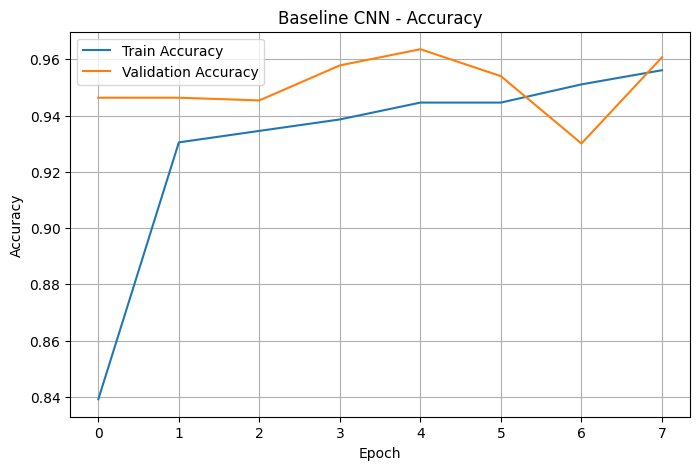

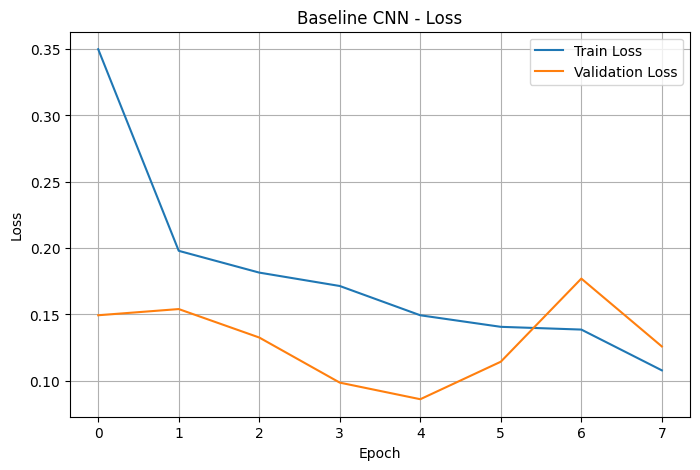

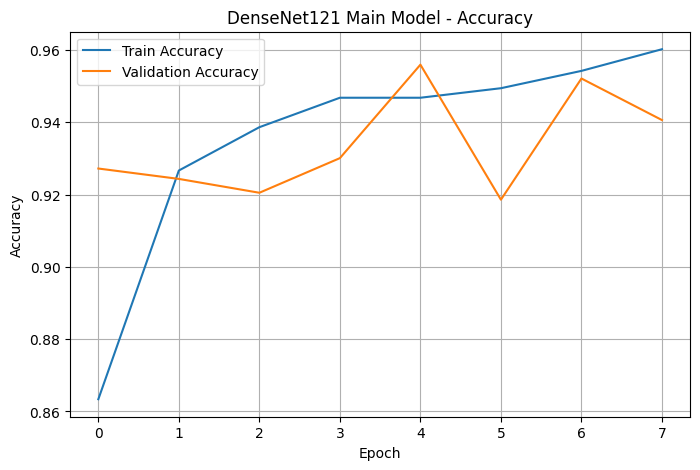

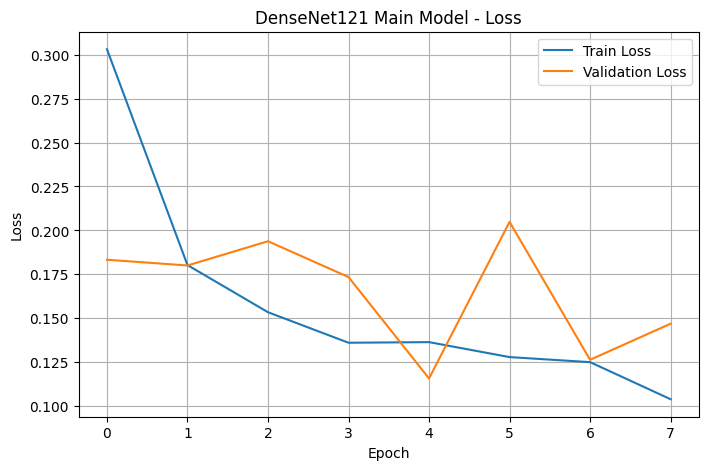

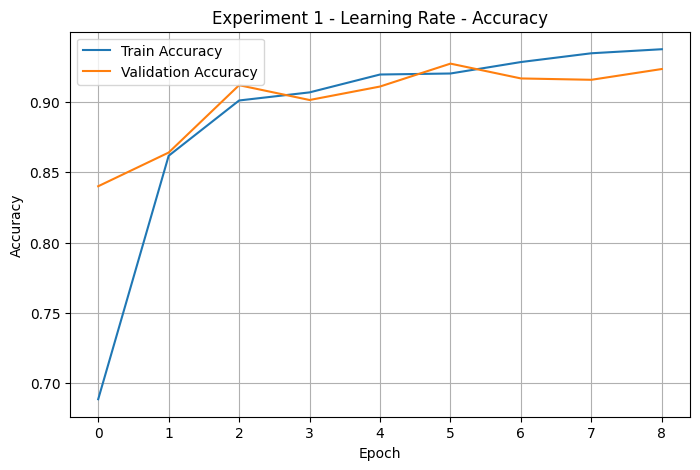

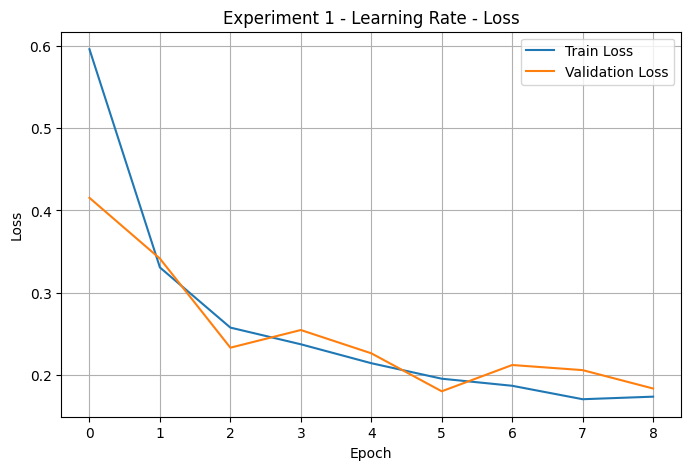

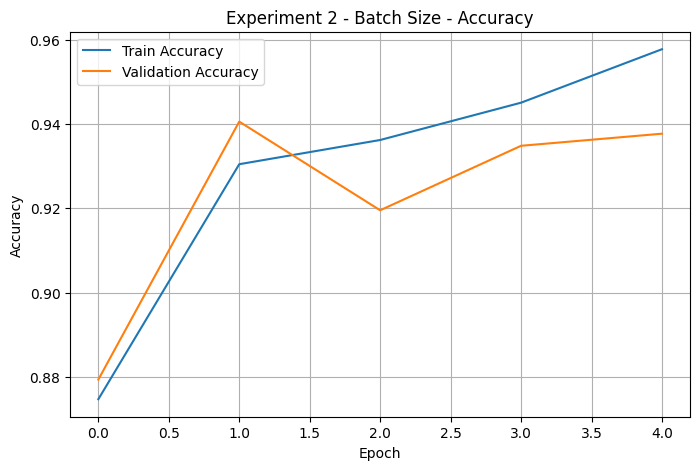

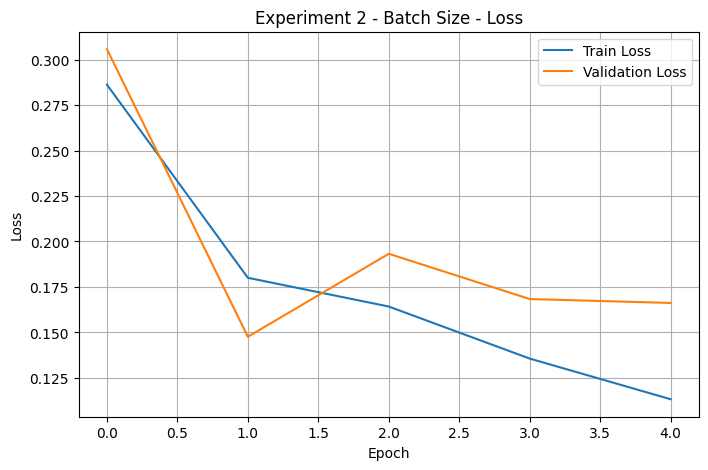

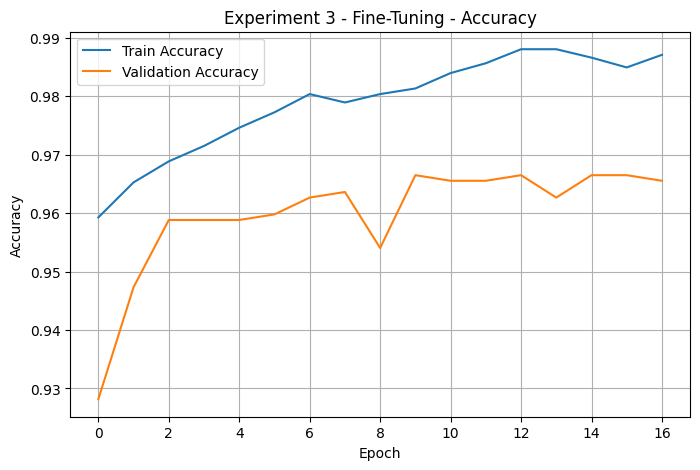

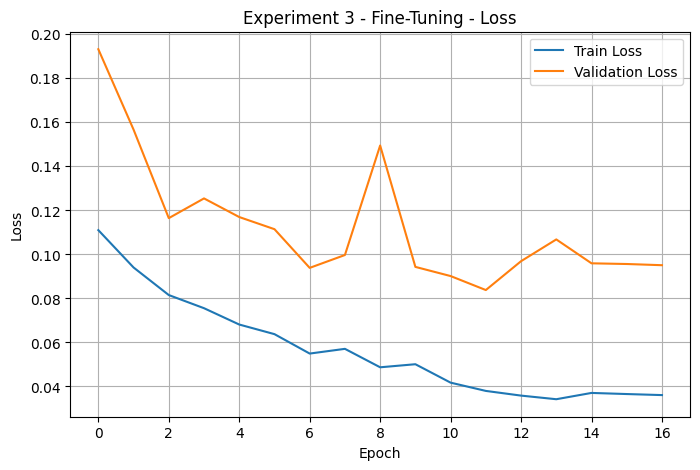

In [15]:
def plot_history(history, title):

    # Accuracy
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history['accuracy'],
        label='Train Accuracy'
    )

    plt.plot(
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )

    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history['loss'],
        label='Train Loss'
    )

    plt.plot(
        history.history['val_loss'],
        label='Validation Loss'
    )

    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()


plot_history(history_baseline, 'Baseline CNN')
plot_history(history, 'DenseNet121 Main Model')
plot_history(history_exp1, 'Experiment 1 - Learning Rate')
plot_history(history_exp2, 'Experiment 2 - Batch Size')
plot_history(history_exp3, 'Experiment 3 - Fine-Tuning')

# 15. Final Model Evaluation

The DenseNet121 main model is evaluated on the original test set.

The test set is used only for final evaluation.

In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Reset generator
test_generator.reset()

# Predictions
predictions = model.predict(
    test_generator
).ravel()

predicted_classes = (
    predictions >= 0.5
).astype(int)

true_classes = test_generator.classes

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=[
            'NORMAL',
            'PNEUMONIA'
        ]
    )
)

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print('Confusion Matrix:')
print(cm)

accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

roc_auc = roc_auc_score(
    true_classes,
    predictions
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

sensitivity = tp / (tp + fn)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'Sensitivity / Recall: {sensitivity:.4f}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 893ms/step
              precision    recall  f1-score   support

      NORMAL       0.96      0.64      0.77       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.85       624

Confusion Matrix:
[[149  85]
 [  6 384]]
Accuracy: 0.8542
ROC-AUC: 0.9578
Specificity: 0.6368
Sensitivity / Recall: 0.9846


# 16. Final Metrics Summary

All metrics are calculated directly from the model predictions.
No values are manually entered.

In [17]:
stats_summary = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision (PNEUMONIA)',
        'Recall (PNEUMONIA)',
        'F1-Score (PNEUMONIA)',
        'Precision (NORMAL)',
        'Recall (NORMAL)',
        'Specificity',
        'ROC-AUC'
    ],

    'Value': [
        accuracy,

        precision_score(
            true_classes,
            predicted_classes,
            pos_label=1
        ),

        recall_score(
            true_classes,
            predicted_classes,
            pos_label=1
        ),

        f1_score(
            true_classes,
            predicted_classes,
            pos_label=1
        ),

        precision_score(
            true_classes,
            predicted_classes,
            pos_label=0
        ),

        recall_score(
            true_classes,
            predicted_classes,
            pos_label=0
        ),

        specificity,
        roc_auc
    ]
})

display(stats_summary)

stats_summary.to_csv(
    f'{PROJECT_DIR}/results/final_metrics.csv',
    index=False
)

,Metric,Value
0,Accuracy,0.854167
1,Precision (PNEUMONIA),0.818763
2,Recall (PNEUMONIA),0.984615
3,F1-Score (PNEUMONIA),0.894063
4,Precision (NORMAL),0.961290
5,Recall (NORMAL),0.636752
6,Specificity,0.636752
7,ROC-AUC,0.957758


# 17. Confusion Matrix

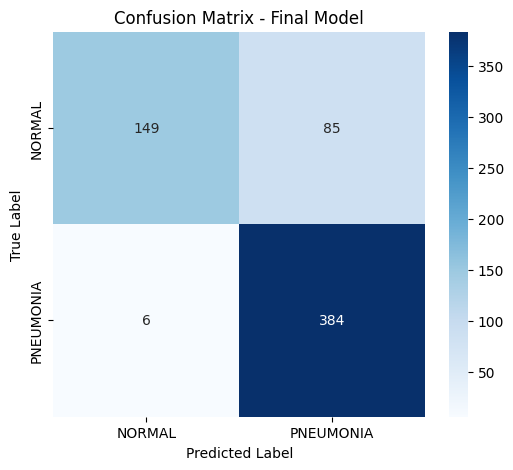

In [18]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'NORMAL',
        'PNEUMONIA'
    ],
    yticklabels=[
        'NORMAL',
        'PNEUMONIA'
    ]
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Final Model')

plt.savefig(
    f'{PROJECT_DIR}/plots/confusion_matrix.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# 18. Error Analysis

We analyze:

- False Positives: Normal images predicted as Pneumonia
- False Negatives: Pneumonia images predicted as Normal

False Negatives are especially important because they represent Pneumonia cases that were missed by the model.

In [19]:
wrong_indices = np.where(
    predicted_classes != true_classes
)[0]

false_positives = np.where(
    (predicted_classes == 1) &
    (true_classes == 0)
)[0]

false_negatives = np.where(
    (predicted_classes == 0) &
    (true_classes == 1)
)[0]

print('Total Errors:', len(wrong_indices))
print('Total Images:', len(true_classes))

print(
    'False Positives:',
    len(false_positives)
)

print(
    'False Negatives:',
    len(false_negatives)
)

print(
    '\nClinical Note:'
)

print(
    'These observations are based on visual inspection '
    'and model predictions. They do not represent a clinical diagnosis.'
)

Total Errors: 91
Total Images: 624
False Positives: 85
False Negatives: 6

Clinical Note:
These observations are based on visual inspection and model predictions. They do not represent a clinical diagnosis.


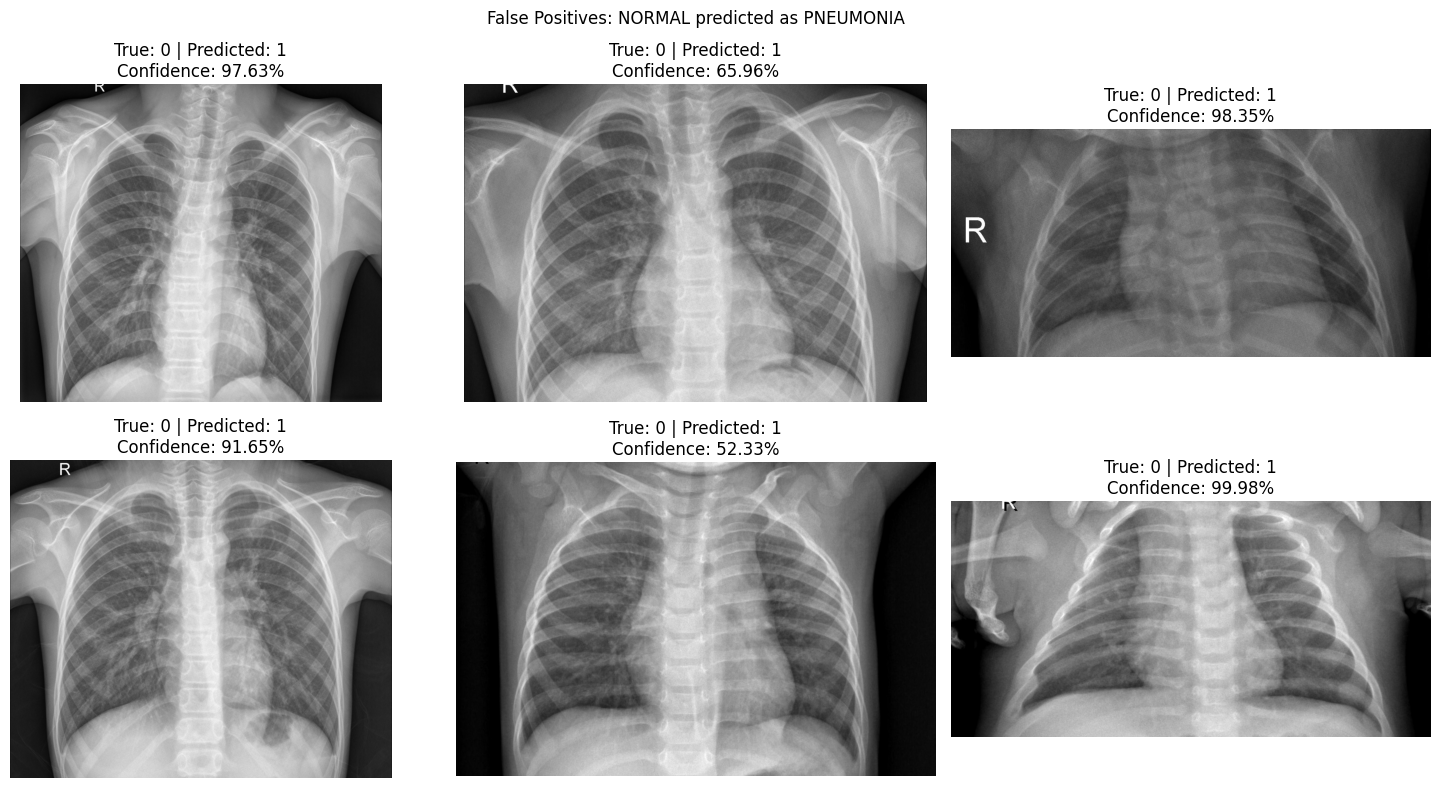

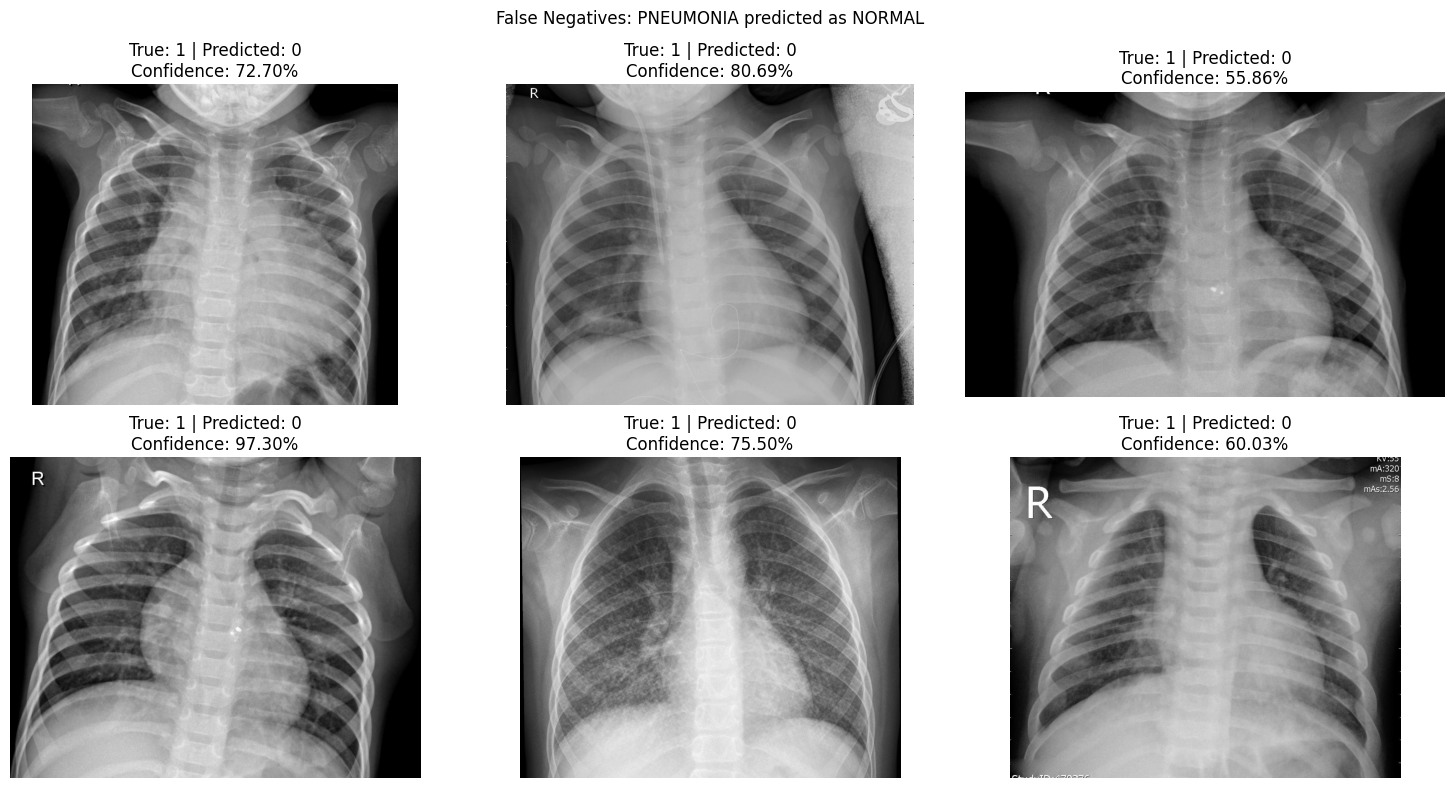

In [20]:
filenames = test_generator.filenames

def show_error_images(
    indices,
    title,
    max_images=6
):

    n = min(
        len(indices),
        max_images
    )

    if n == 0:
        print(f'No errors found for: {title}')
        return

    plt.figure(
        figsize=(15, 8)
    )

    for i, idx in enumerate(indices[:n]):

        img_path = os.path.join(
            TEST_DIR,
            filenames[idx]
        )

        img = plt.imread(img_path)

        plt.subplot(
            2,
            3,
            i + 1
        )

        plt.imshow(
            img,
            cmap='gray'
        )

        probability = predictions[idx]

        if predicted_classes[idx] == 1:
            confidence = probability
        else:
            confidence = 1 - probability

        plt.title(
            f'True: {true_classes[idx]} | '
            f'Predicted: {predicted_classes[idx]}\n'
            f'Confidence: {confidence:.2%}'
        )

        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_error_images(
    false_positives,
    'False Positives: NORMAL predicted as PNEUMONIA'
)

show_error_images(
    false_negatives,
    'False Negatives: PNEUMONIA predicted as NORMAL'
)

# 19. Error Summary

In [21]:
error_summary = pd.DataFrame({

    'Error Type': [
        'False Positives',
        'False Negatives'
    ],

    'Total': [
        len(false_positives),
        len(false_negatives)
    ],

    'Percentage of Total Images': [
        f'{len(false_positives) / len(true_classes) * 100:.2f}%',
        f'{len(false_negatives) / len(true_classes) * 100:.2f}%'
    ]
})

display(error_summary)

error_summary.to_csv(
    f'{PROJECT_DIR}/results/error_summary.csv',
    index=False
)

,Error Type,Total,Percentage of Total Images
0,False Positives,85,13.62%
1,False Negatives,6,0.96%


# 20. Model Interpretability — Grad-CAM

To open the "black box" of the DenseNet121 model, we use **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

Grad-CAM produces a heatmap over the input X-ray showing **which regions of the image most influenced the model's PNEUMONIA prediction**. This is done by:

1. Taking the gradients of the predicted class score with respect to the activations of the last convolutional layer.
2. Pooling those gradients to get an "importance weight" per feature map.
3. Combining the feature maps using these weights to produce a coarse localization heatmap.

We apply this to:
- Correctly classified PNEUMONIA cases → to check the model focuses on the lung fields / opacities.
- False Negative cases (from the Error Analysis above) → to check whether the model was looking at irrelevant regions (bones, edges, text markers) instead of the lungs, which may explain the missed diagnosis.

In [22]:
import tensorflow as tf
import cv2


def get_last_conv_layer_name(keras_model):
    """Automatically find the name of the last Conv2D layer in the model
    (this is the layer Grad-CAM needs activations/gradients from)."""
    for layer in reversed(keras_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('No Conv2D layer found in the model.')


def get_img_array(img_path, size=IMG_SIZE):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = array / 255.0
    array = np.expand_dims(array, axis=0)
    return array


def make_gradcam_heatmap(img_array, keras_model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [keras_model.inputs],
        [keras_model.get_layer(last_conv_layer_name).output, keras_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Single-unit sigmoid output -> channel 0 is the PNEUMONIA score
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = plt.imread(img_path)

    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    if img.shape[-1] == 4:
        img = img[..., :3]

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = (heatmap_colored * alpha + img * (1 - alpha)).astype(np.uint8)
    return superimposed


last_conv_layer_name = get_last_conv_layer_name(model)
print('Grad-CAM will use the last convolutional layer:', last_conv_layer_name)

Grad-CAM will use the last convolutional layer: conv5_block16_2_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_4']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


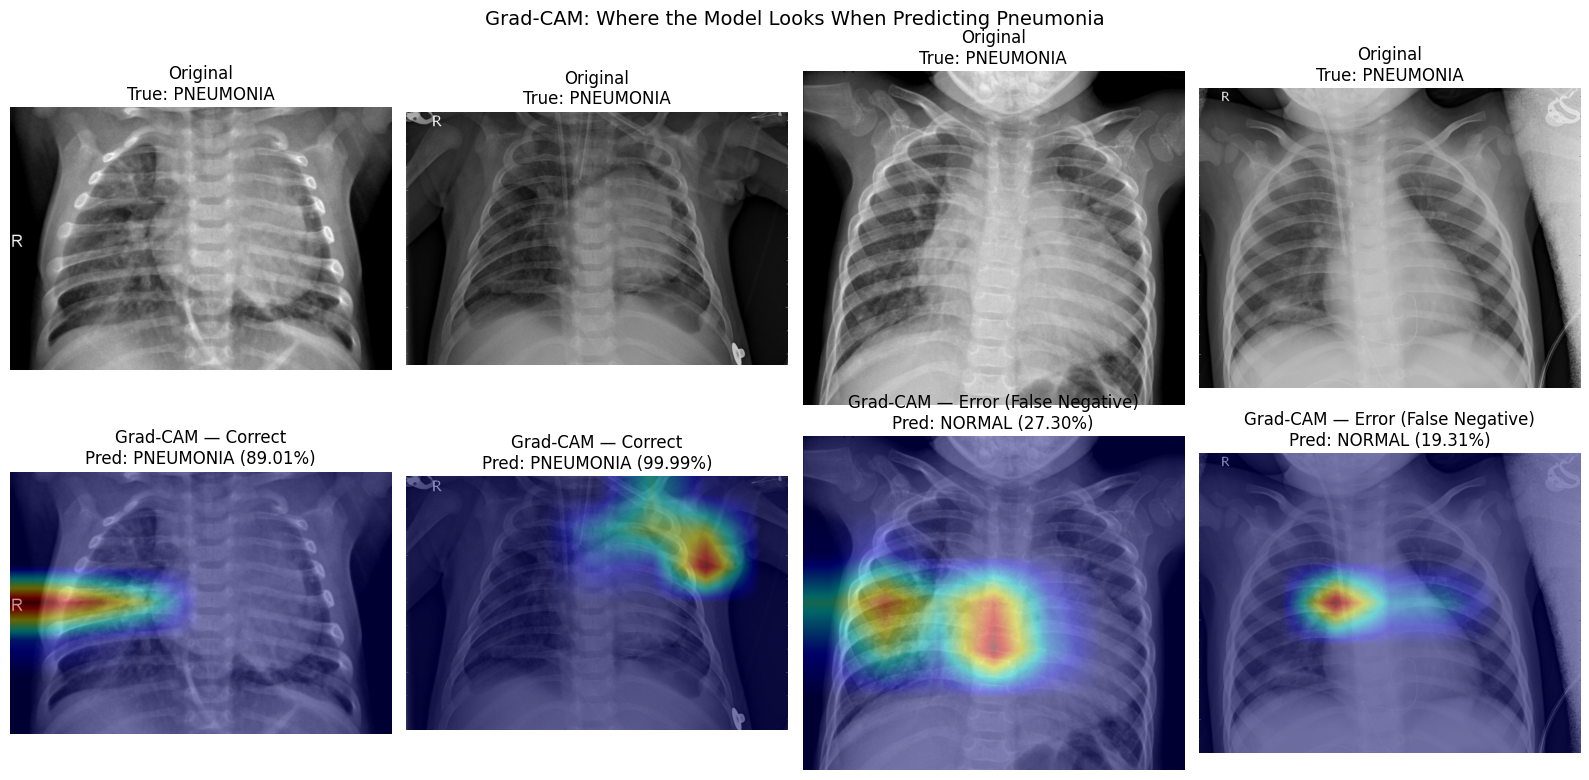

In [23]:
# Pick example images: correctly predicted PNEUMONIA cases + False Negatives
correctly_predicted_pneumonia = np.where(
    (predicted_classes == 1) & (true_classes == 1)
)[0]

sample_indices = list(correctly_predicted_pneumonia[:2]) + list(false_negatives[:2])

n = len(sample_indices)
plt.figure(figsize=(4 * n, 8))

for i, idx in enumerate(sample_indices):
    img_path = os.path.join(TEST_DIR, filenames[idx])
    img_array = get_img_array(img_path)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    superimposed = overlay_gradcam(img_path, heatmap)

    is_correct = predicted_classes[idx] == true_classes[idx]
    status = 'Correct' if is_correct else 'Error (False Negative)'
    pred_label = 'PNEUMONIA' if predicted_classes[idx] == 1 else 'NORMAL'

    plt.subplot(2, n, i + 1)
    plt.imshow(plt.imread(img_path), cmap='gray')
    plt.title('Original\nTrue: PNEUMONIA')
    plt.axis('off')

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(superimposed)
    plt.title(f'Grad-CAM — {status}\nPred: {pred_label} ({predictions[idx]:.2%})')
    plt.axis('off')

plt.suptitle('Grad-CAM: Where the Model Looks When Predicting Pneumonia', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()